In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adeelasaleem/regressiontraindataset/train (1).csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/adeelasaleem/regressiontraindataset/train (1).csv')

print( df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
#copy bnana to maintain original array
df_clean=df.copy()
#id drop 
df_clean=df_clean.drop(columns=['Id'])
#handle missing vlaues 

#above 50% missing--> drop
thresh=len(df_clean)*0.5
df_clean=df_clean.dropna(thresh=thresh,axis=1)
#numeric col if misisng--> median
num_cols=df_clean.select_dtypes(include='number').columns
for col in num_cols:
    df_clean[col]=df_clean[col].fillna(df_clean[col].median())
#categoical msisng-->mode
cat_cols = df_clean.select_dtypes(include='object').columns
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
#label encoding on categorical
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in cat_cols:
    df_clean[col]=le.fit_transform(df_clean[col].astype(str))
print('missing:',df_clean.isnull().sum().sum())
print('updated shape:',df_clean.shape)

print("Text columns remaining:", df_clean.select_dtypes(include='object').shape[1])
print("Shape:", df_clean.shape)

missing: 0
updated shape: (1460, 75)
Text columns remaining: 0
Shape: (1460, 75)


In [4]:
# define features&target
X=df_clean.drop(columns=['SalePrice']).values
y=df_clean['SalePrice'].values.reshape(-1,1)

print('X-shape:',X.shape)
print('y-Shape:',y.shape)

X-shape: (1460, 74)
y-Shape: (1460, 1)


In [5]:
#train/test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1168, 74)
X_test: (292, 74)
y_train: (1168, 1)
y_test: (292, 1)


In [7]:
# standardize 
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('mean:',X_train_scaled.mean().round(3))
print("Std:", X_train_scaled.std().round(3))

mean: 0.0
Std: 1.0


In [8]:
 # bias column add
n=X_train_scaled.shape[0]  #samples 1168
features=X_train_scaled.shape[1] #features
X_train_b=np.c_[np.ones((n,1)),X_train_scaled]
X_test_b=np.c_[np.ones((292,1)),X_test_scaled]  #(292, 1) ek tuple hai--> shape btata 292 rows 1 col

# initialize weights 
np.random.seed(42)
theta = np.random.randn(features + 1, 1)

print("X_train_b shape:", X_train_b.shape)
print("theta shape:", theta.shape)
print("Starting theta:", theta[:3].flatten().round(3))


X_train_b shape: (1168, 75)
theta shape: (75, 1)
Starting theta: [ 0.497 -0.138  0.648]


In [9]:
import numpy as np

# Check karo pehle
print("X_train_scaled shape:", X_train_scaled.shape)

# Bias add karo
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# Weights
np.random.seed(42)
theta = np.random.randn(X_train_b.shape[1], 1)

print("X_train_b shape:", X_train_b.shape)
print("X_test_b shape:", X_test_b.shape)
print("theta shape:", theta.shape)

X_train_scaled shape: (1168, 74)
X_train_b shape: (1168, 75)
X_test_b shape: (292, 75)
theta shape: (75, 1)


In [17]:
# hyperparameters
learning_rate=0.01
n_iterations=1000  # less overfitting ,more better learning
n = X_train_b.shape[0]  #n = 1168 samples for gradient average 
loss_history=[]
for i in range(n_iterations):
    #predict
    y_predict=X_train_b.dot(theta)
    #error 
    error=y_pred-y_train
    #gradient
    gradient = X_train_b.T.dot(error) / n
    #update
    theta = theta - learning_rate * gradient
    #Loss save 
    loss = np.mean(error**2)
    loss_history.append(loss)
    
    # Har 100 iteration pe print
    if i % 100 == 0:
        print(f"Iteration {i}: Loss = {loss:.2f}")

print("Final Loss:", loss_history[-1].round(2))

    
    

Iteration 0: Loss = 38881168497.46
Iteration 100: Loss = 38881168497.46
Iteration 200: Loss = 38881168497.46
Iteration 300: Loss = 38881168497.46
Iteration 400: Loss = 38881168497.46
Iteration 500: Loss = 38881168497.46
Iteration 600: Loss = 38881168497.46
Iteration 700: Loss = 38881168497.46
Iteration 800: Loss = 38881168497.46
Iteration 900: Loss = 38881168497.46
Final Loss: 38881168497.46


In [11]:
# y ko log transform kiya
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("y_train original:", y_train[:3].flatten())
print("y_train log:", y_train_log[:3].flatten().round(3))

y_train original: [145000 178000  85000]
y_train log: [11.884 12.09  11.35 ]


In [12]:
# Weights reset karo
np.random.seed(42)
theta = np.random.randn(X_train_b.shape[1], 1)

learning_rate = 0.01
n_iterations = 1000
n = X_train_b.shape[0]
loss_history = []

for i in range(n_iterations):
    y_pred = X_train_b.dot(theta)
    error = y_pred - y_train_log
    gradient = X_train_b.T.dot(error) / n
    theta = theta - learning_rate * gradient
    loss = np.mean(error**2)
    loss_history.append(loss)
    
    if i % 100 == 0:
        print(f"Iteration {i}: Loss = {loss:.4f}")

print("\nFinal Loss:", loss_history[-1].round(4))

Iteration 0: Loss = 190.6117
Iteration 100: Loss = 27.5410
Iteration 200: Loss = 5.3354
Iteration 300: Loss = 1.5462
Iteration 400: Loss = 0.6836
Iteration 500: Loss = 0.3942
Iteration 600: Loss = 0.2598
Iteration 700: Loss = 0.1843
Iteration 800: Loss = 0.1373
Iteration 900: Loss = 0.1060

Final Loss: 0.0844


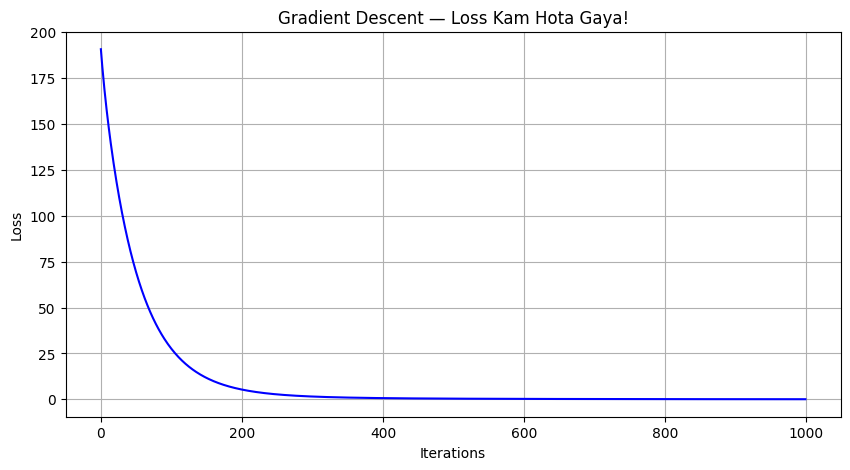

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(loss_history, color='blue')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Gradient Descent — Loss Kam Hota Gaya!')
plt.grid(True)
plt.show()

In [14]:
from sklearn.metrics import r2_score
import numpy as np

# Test data pe predict karo
y_pred_log = X_test_b.dot(theta)

# Log se original price pe wapas
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

# RMSE
rmse = np.sqrt(np.mean((y_test_actual - y_pred_actual)**2))

# R2
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"RMSE: ${rmse:,.0f}")
print(f"R2 Score: {r2:.4f}")

RMSE: $60,490
R2 Score: 0.5230


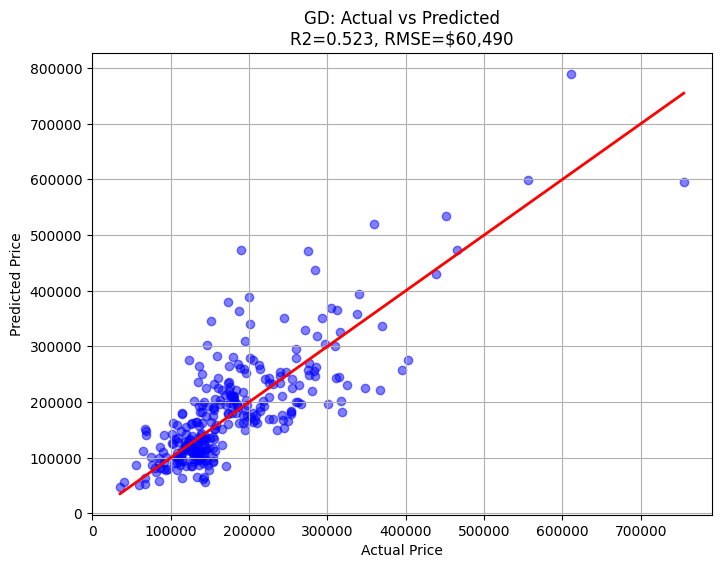

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_actual, 
            alpha=0.5, color='blue')
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         color='red', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'GD: Actual vs Predicted\nR2={r2:.3f}, RMSE=${rmse:,.0f}')
plt.grid(True)
plt.show()